# Data import

In [1]:
import pandas as pd
import glob
files = glob.glob("/home/NAS/kykim/RNA_seq_data_ovary/Readcount/*featureCounts.txt")
files = [f for f in files if not f.endswith(".summary")]
print(f"Found {len(files)} files to check.")

geneid_lists = []
for f in files:
    df = pd.read_csv(f, sep='\t', comment='#', header=0)
    geneid_lists.append(df['Geneid'])
base_geneid = geneid_lists[0]
all_match = True

for i, gid in enumerate(geneid_lists[1:], start=1):
    if not base_geneid.equals(gid):
        print(f"Geneid mismatch in file: {files[i]}")
        all_match = False

if all_match:
    print("All Geneid columns match across files.")
else:
    print("There are mismatches in some files.")

Found 22 files to check.
All Geneid columns match across files.


In [2]:
files = glob.glob("/home/NAS/kykim/RNA_seq_data_ovary/Readcount/*featureCounts.txt")
files = [f for f in files if not f.endswith(".summary")]
print(f"Found {len(files)} files to check.")

geneid_lists = []
strand_lists = []

for f in files:
    df = pd.read_csv(f, sep='\t', comment='#', header=0)
    geneid_lists.append(df['Geneid'])
    strand_lists.append(df['Strand'])

base_geneid = geneid_lists[0]
all_geneid_match = True
for i, gid in enumerate(geneid_lists[1:], start=1):
    if not base_geneid.equals(gid):
        print(f"Geneid mismatch in file: {files[i]}")
        all_geneid_match = False
if all_geneid_match:
    print("All Geneid columns match across files.")
else:
    print("There are mismatches in some files.")
base_strand = strand_lists[0]
all_strand_match = True
for i, strand in enumerate(strand_lists[1:], start=1):
    if not base_strand.equals(strand):
        print(f"Strand mismatch in file: {files[i]}")
        all_strand_match = False
if all_strand_match:
    print("All Strand columns match across files.")
else:
    print("There are mismatches in Strand in some files.")

Found 22 files to check.
All Geneid columns match across files.
All Strand columns match across files.


In [3]:
###########################
#### Gene information #####
###########################

In [4]:
file_path = "/home/NAS/kykim/RNA_seq_data_ovary/Readcount/CRR230027_featureCounts.txt"
df = pd.read_csv(file_path, sep='\t', comment='#', header=0)
gene_info = df[['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length']].set_index('Geneid')

In [5]:
###########################
####### Gene Matrix #######
###########################

In [6]:
import pandas as pd
import glob
import os

files = glob.glob("/home/NAS/kykim/RNA_seq_data_ovary/Readcount/*featureCounts.txt")
files = [f for f in files if not f.endswith(".summary")]

count_dfs = []
for f in files:
    df = pd.read_csv(f, sep='\t', comment='#', header=0)
    sample_name = os.path.basename(f).replace("_featureCounts.txt", "")
    count_df = df[['Geneid', df.columns[-1]]].copy()
    count_df = count_df.rename(columns={df.columns[-1]: sample_name})
    count_df = count_df.set_index('Geneid')
    count_dfs.append(count_df)

data = pd.concat(count_dfs, axis=1)
meta = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/meta.csv")
mapping = dict(zip(meta.iloc[:, 0], meta.iloc[:, 1]))

print("Indexing process ....")
for col in data.columns:
    new_name = mapping.get(col)
    if new_name:
        print(f"{col} → {new_name}  O")
    else:
        print(f"{col} → (매칭 없음)  X")

data.columns = [mapping.get(col, col) for col in data.columns]
data.index.name = None

Indexing process ....
CRR230019 → Ovary3W_R1  O
CRR230016 → Ovary0D_R1  O
CRR230031 → Ovary6M_R3  O
CRR230022 → Ovary2M_R1  O
CRR230025 → Ovary3M_R1  O
CRR230034 → Ovary9M_R3  O
CRR230023 → Ovary2M_R2  O
CRR230032 → Ovary9M_R1  O
CRR230028 → Ovary3M_R4  O
CRR230024 → Ovary2M_R3  O
CRR230035 → Ovary1Y_R1  O
CRR230018 → Ovary0D_R3  O
CRR230036 → Ovary1Y_R2  O
CRR230037 → Ovary1Y_R3  O
CRR230020 → Ovary3W_R2  O
CRR230033 → Ovary9M_R2  O
CRR230027 → Ovary3M_R3  O
CRR230029 → Ovary6M_R1  O
CRR230021 → Ovary3W_R3  O
CRR230030 → Ovary6M_R2  O
CRR230017 → Ovary0D_R2  O
CRR230026 → Ovary3M_R2  O


# Gene characterization

In [7]:
gene_info['Chr_clean'] = gene_info['Chr'].str.split(';').str[0]
def clean_strand(s):
    if pd.isna(s) or s.strip() == '':
        return 'NA'
    s = s.strip()
    strands = list(set(s.split(';')))
    if len(strands) == 1:
        return strands[0]
    else:
        return 'mixed'

gene_info['Strand_clean'] = gene_info['Strand'].apply(clean_strand)

In [8]:
import mygene

mg = mygene.MyGeneInfo()
gene_ids = list(data.index)
gene_map = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol', species='mouse')
mapping_df = pd.DataFrame(gene_map)[['query', 'symbol']].dropna().drop_duplicates('query')
data = data.loc[mapping_df['query']]
data.index = mapping_df.set_index('query').loc[data.index, 'symbol']
data = data.groupby(data.index).sum()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found dup hits:	[('ENSMUSG00000106441', 2), ('ENSMUSG00000072694', 2), ('ENSMUSG00000112376', 2), ('ENSMUSG000001152
637 input query terms found no hit:	['ENSMUSG00000100827', 'ENSMUSG00000101722', 'ENSMUSG00000100334', 'ENSMUSG00000101903', 'ENSMUSG000


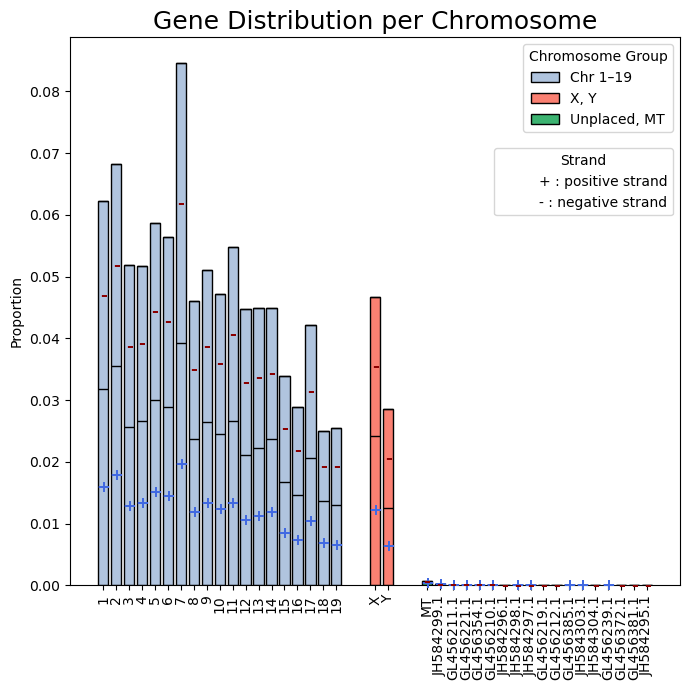

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

counts = gene_info['Chr_clean'].value_counts()
proportion = counts / counts.sum()

autosomes = [str(i) for i in range(1, 20)]
sex_mt = ['X', 'Y']
group1 = proportion[autosomes]
group2 = proportion[sex_mt]
group3 = proportion[~proportion.index.isin(autosomes + sex_mt)]

x1 = np.arange(len(group1))
x2 = np.arange(len(group2)) + len(x1) + 2
x3 = np.arange(len(group3)) + len(x1) + len(x2) + 4
x_all = np.concatenate([x1, x2, x3])
labels = list(group1.index) + list(group2.index) + list(group3.index)

plt.figure(figsize=(7,7))
plt.bar(x1, group1.values, color='lightsteelblue', edgecolor='black', label='Chr 1–19')
plt.bar(x2, group2.values, color='salmon', edgecolor='black', label='X, Y')
plt.bar(x3, group3.values, color='mediumseagreen', edgecolor='black', label='Unplaced, MT')

strand_prop = (
    gene_info.groupby('Chr_clean')['Strand_clean']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
strand_order = ['+', '-']
strand_colors = {'+': 'royalblue', '-': 'darkred'}

for x, chr_name in zip(x_all, labels):
    if chr_name not in strand_prop.index:
        continue
    total_height = proportion[chr_name]
    y_bottom = 0
    for strand_type in strand_order:
        frac = strand_prop.loc[chr_name].get(strand_type, 0)
        if frac == 0:
            continue
        y_top = y_bottom + frac * total_height
        plt.hlines(y=y_top, xmin=x - 0.4, xmax=x + 0.4, color='black', linewidth=1)
        if frac >= 0.01:
            y_center = (y_bottom + y_top) / 2
            plt.text(
                x, y_center, strand_type,
                ha='center', va='center',
                fontsize=12, color=strand_colors[strand_type],
                fontweight='bold'
            )
        y_bottom = y_top

plt.xticks(x_all, labels, rotation=90)
plt.ylabel('Proportion')
plt.title('Gene Distribution per Chromosome', fontsize=18)

legend1 = plt.legend(
    loc='upper right',
    frameon=True,
    fontsize=10,
    title='Chromosome Group'
)

strand_legend_elements = [
    Patch(facecolor='white', edgecolor='none', label='+ : positive strand', alpha=0.0),
    Patch(facecolor='white', edgecolor='none', label='- : negative strand', alpha=0.0)
]
plt.legend(
    handles=strand_legend_elements,
    loc='upper right',
    bbox_to_anchor=(1, 0.81),
    frameon=True,
    title='Strand'
)

plt.gca().add_artist(legend1)
plt.tight_layout()
plt.show()


In [10]:
data.to_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_raw.csv")

# Data QC

In [28]:
data = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_raw.csv", index_col=0) # raw
# data = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_vsd_preprocess.csv", index_col=0) # preprocess

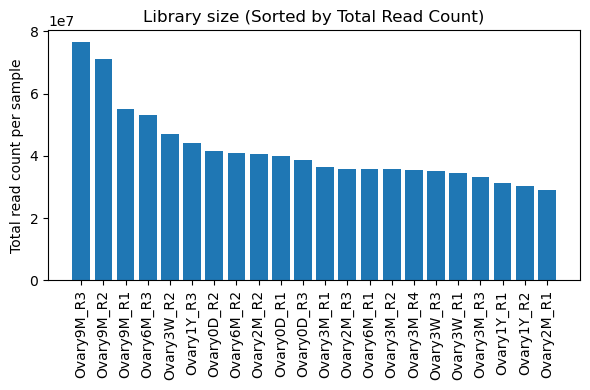

In [29]:
library_size = data.sum(axis=0)
library_size_sorted = library_size.sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(library_size_sorted.index, library_size_sorted.values)
plt.xticks(rotation=90)
plt.ylabel("Total read count per sample")
plt.title("Library size (Sorted by Total Read Count)")
plt.tight_layout()
plt.show()

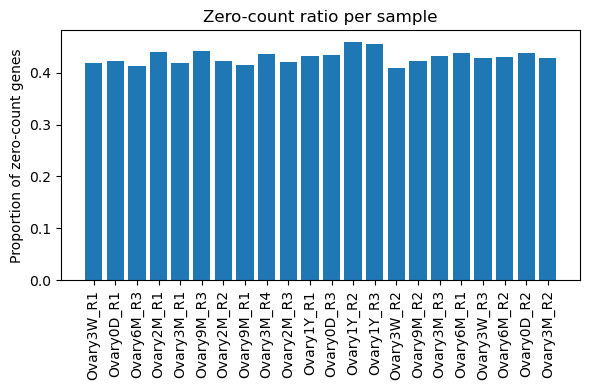

In [30]:
zero_ratio = (data == 0).sum(axis=0) / data.shape[0]
plt.figure(figsize=(6,4))
plt.bar(zero_ratio.index, zero_ratio.values)
plt.xticks(rotation=90)
plt.ylabel("Proportion of zero-count genes")
plt.title("Zero-count ratio per sample")
plt.tight_layout()
plt.show()


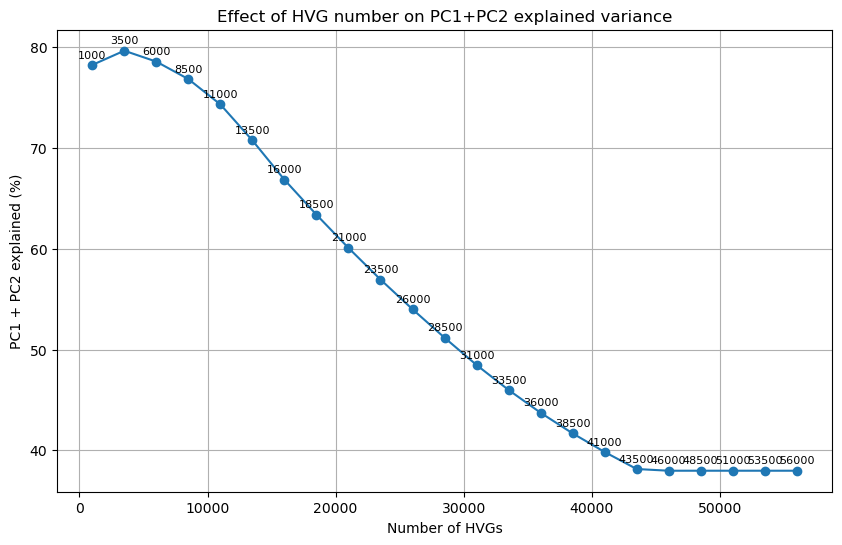

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

log_data = data
hvg_numbers = list(range(1000, 56087, 2500))
explained_sum = []

for n_genes in hvg_numbers:
    gene_var = log_data.var(axis=1)
    top_genes = gene_var.sort_values(ascending=False).index[:n_genes]
    log_data_hv = log_data.loc[top_genes]
    norm_data = StandardScaler().fit_transform(log_data_hv.T)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(norm_data)
    pc1_var = pca.explained_variance_ratio_[0]
    pc2_var = pca.explained_variance_ratio_[1]
    explained_sum.append((pc1_var + pc2_var) * 100)

plt.figure(figsize=(10,6))
plt.plot(hvg_numbers, explained_sum, marker='o', linestyle='-')
#plt.axhline(50, color='red')
plt.xlabel("Number of HVGs")
plt.ylabel("PC1 + PC2 explained (%)")
plt.title("Effect of HVG number on PC1+PC2 explained variance")
plt.grid(True)

for x, y in zip(hvg_numbers, explained_sum):
    plt.text(x, y+0.5, f"{x}", fontsize=8, ha='center', va='bottom')

df = pd.DataFrame({
    "HVGs": hvg_numbers,
    "PC1+PC2": explained_sum
})

exact_50 = df[df["PC1+PC2"].round(2) == 50.00]
for _, row in exact_50.iterrows():
    x = row["HVGs"]
    y = row["PC1+PC2"]
    plt.scatter(x, y, color='red', s=80)
    plt.text(x, y+1, f"HVG={x}\n50%", color='red',
             fontsize=10, ha='center', va='bottom', fontweight='bold')
plt.show()

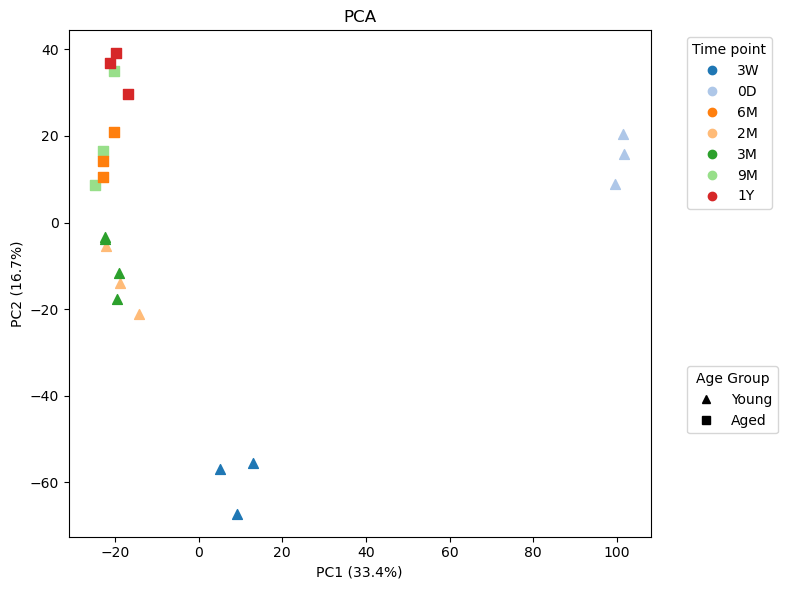

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

log_data = np.log1p(data)
#log_data = data
gene_var = log_data.var(axis=1)
top_genes = gene_var.sort_values(ascending=False).index[:5125]
log_data_hv = log_data.loc[top_genes]
norm_data = StandardScaler().fit_transform(log_data_hv.T)

pca = PCA(n_components=2)
pcs = pca.fit_transform(norm_data)
pca_df = pd.DataFrame(pcs, columns=['PC1','PC2'], index=data.columns)

triangle_groups = ['0D', '3W', '2M', '3M']
pca_df['Group'] = pca_df.index.str[5:7]
pca_df['AgeGroup'] = ['Young' if g in triangle_groups else 'Aged' for g in pca_df['Group']]
unique_groups = pca_df['Group'].unique()
colors = plt.cm.tab20.colors
group_color = {g: colors[i % len(colors)] for i, g in enumerate(unique_groups)}
age_markers = {'Young':'^','Aged':'s'}

plt.figure(figsize=(8,6))

for i, row in pca_df.iterrows():
    plt.scatter(row['PC1'], row['PC2'], color=group_color[row['Group']],
                marker=age_markers[row['AgeGroup']], s=50)

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var:.1f}%)")
plt.title("PCA")

group_legend_handles = [plt.Line2D([], [], color=group_color[g], marker='o', linestyle='',
                                   markersize=6, label=g) for g in unique_groups]
group_legend = plt.legend(handles=group_legend_handles, title="Time point",
                          bbox_to_anchor=(1.05, 1), loc='upper left')
age_legend_handles = [plt.Line2D([], [], color='black', marker=age_markers[a], linestyle='',
                                 markersize=6, label=a) for a in age_markers]
age_legend = plt.legend(handles=age_legend_handles, title="Age Group",
                        bbox_to_anchor=(1.05, 0.35), loc='upper left')

plt.gca().add_artist(group_legend)
plt.tight_layout()
plt.show()

In [35]:
hvg_5125_norm = pd.DataFrame(norm_data, index=data.columns, columns=top_genes).T

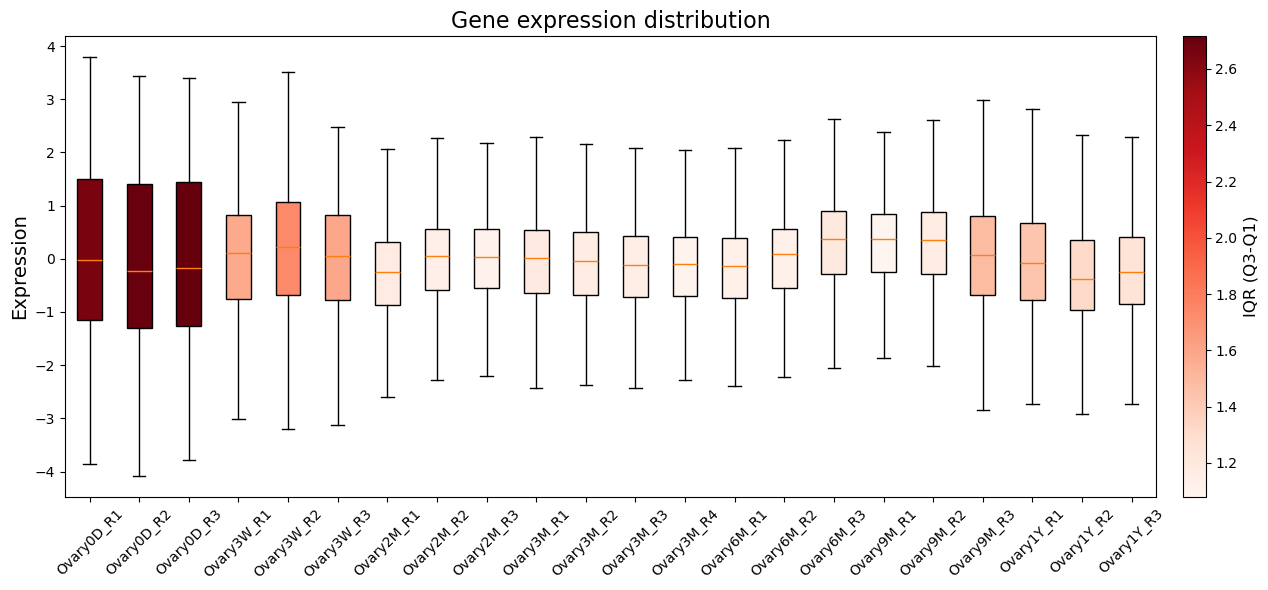

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import matplotlib.colors as mcolors
import matplotlib.cm as cm

sample_order = [
    "Ovary0D_R1","Ovary0D_R2","Ovary0D_R3",
    "Ovary3W_R1","Ovary3W_R2","Ovary3W_R3",
    "Ovary2M_R1","Ovary2M_R2","Ovary2M_R3",
    "Ovary3M_R1","Ovary3M_R2","Ovary3M_R3","Ovary3M_R4",
    "Ovary6M_R1","Ovary6M_R2","Ovary6M_R3",
    "Ovary9M_R1","Ovary9M_R2","Ovary9M_R3",
    "Ovary1Y_R1","Ovary1Y_R2","Ovary1Y_R3"
]

hvg_5125_norm_ordered = hvg_5125_norm[sample_order]

iqr_values = hvg_5125_norm_ordered.quantile(0.75) - hvg_5125_norm_ordered.quantile(0.25)
norm = mcolors.Normalize(vmin=iqr_values.min(), vmax=iqr_values.max())
cmap = plt.cm.Reds

fig, ax = plt.subplots(figsize=(14,6))
boxplots = ax.boxplot(hvg_5125_norm_ordered.values, showfliers=False, patch_artist=True)

for patch, iqr in zip(boxplots['boxes'], iqr_values):
    patch.set_facecolor(cmap(norm(iqr)))
    patch.set_edgecolor('black')

ax.set_xticks(range(1, len(sample_order)+1))
ax.set_xticklabels(sample_order, rotation=45, fontsize=10)
ax.set_ylabel("Expression", fontsize=14)
ax.set_title("Gene expression distribution", fontsize=16)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('IQR (Q3-Q1)', fontsize=12)

plt.tight_layout()
plt.show()


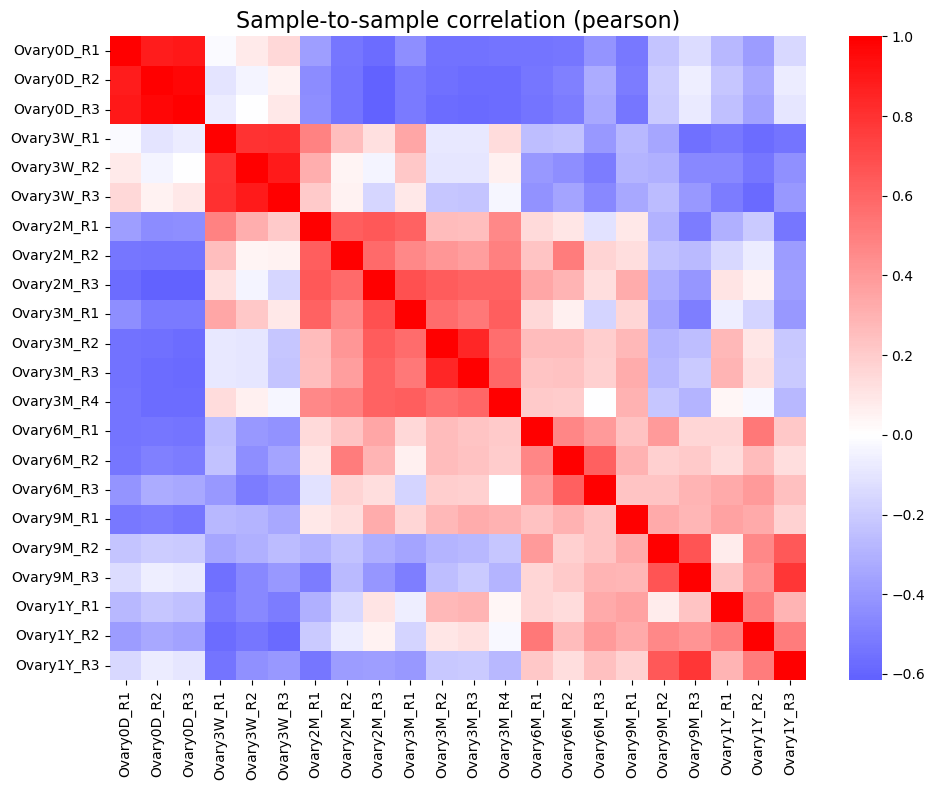

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_order = [
    "Ovary0D_R1","Ovary0D_R2","Ovary0D_R3",
    "Ovary3W_R1","Ovary3W_R2","Ovary3W_R3",
    "Ovary2M_R1","Ovary2M_R2","Ovary2M_R3",
    "Ovary3M_R1","Ovary3M_R2","Ovary3M_R3","Ovary3M_R4",
    "Ovary6M_R1","Ovary6M_R2","Ovary6M_R3",
    "Ovary9M_R1","Ovary9M_R2","Ovary9M_R3",
    "Ovary1Y_R1","Ovary1Y_R2","Ovary1Y_R3"
]

corr = hvg_5125_norm[sample_order].corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='bwr', center=0, xticklabels=sample_order, yticklabels=sample_order)
plt.title("Sample-to-sample correlation (pearson)",fontsize=16)
plt.tight_layout()
plt.show()


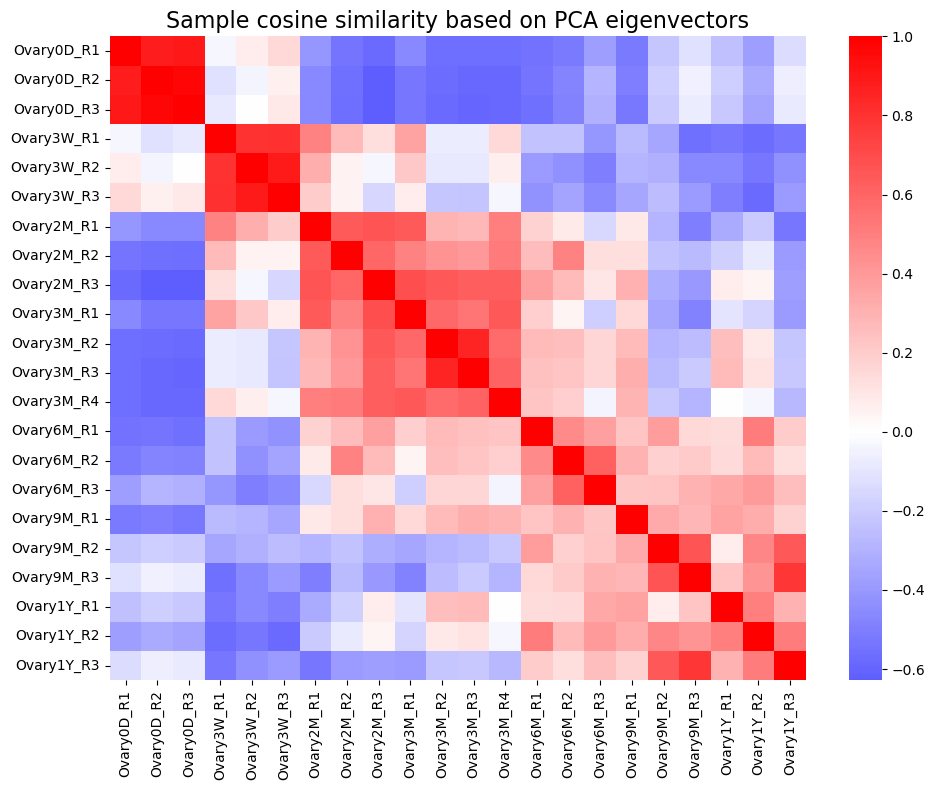

In [60]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

sample_order = [
    "Ovary0D_R1","Ovary0D_R2","Ovary0D_R3",
    "Ovary3W_R1","Ovary3W_R2","Ovary3W_R3",
    "Ovary2M_R1","Ovary2M_R2","Ovary2M_R3",
    "Ovary3M_R1","Ovary3M_R2","Ovary3M_R3","Ovary3M_R4",
    "Ovary6M_R1","Ovary6M_R2","Ovary6M_R3",
    "Ovary9M_R1","Ovary9M_R2","Ovary9M_R3",
    "Ovary1Y_R1","Ovary1Y_R2","Ovary1Y_R3"
]

X = hvg_5125_norm[sample_order].T.values
pca = PCA(n_components=min(X.shape))
PCs = pca.fit_transform(X)
cos_sim = cosine_similarity(PCs)

cos_sim_df = pd.DataFrame(cos_sim, index=sample_order, columns=sample_order)

plt.figure(figsize=(10,8))
sns.heatmap(cos_sim_df, cmap='bwr', center=0, xticklabels=sample_order, yticklabels=sample_order)
plt.title("Sample cosine similarity based on PCA eigenvectors", fontsize=16)
plt.tight_layout()
plt.show()


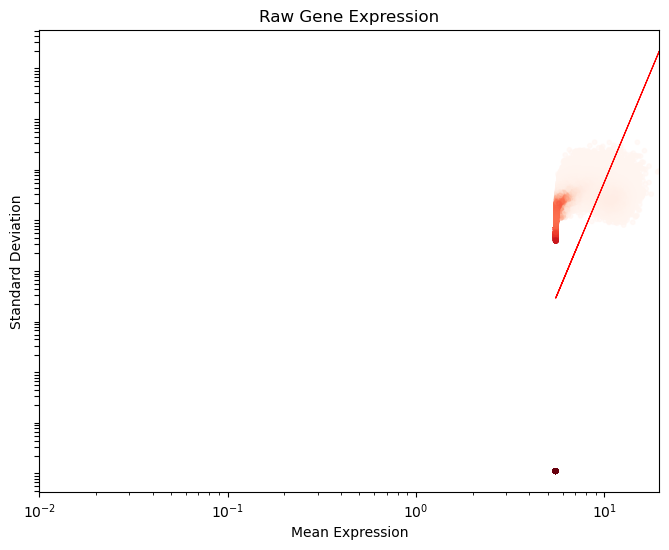

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import LogLocator
from scipy.stats import gaussian_kde

gene_mean = data.mean(axis=1)
gene_sd = data.std(axis=1)

gene_mean_safe = gene_mean + 1e-6
gene_sd_safe = gene_sd + 1e-6

plt.figure(figsize=(8,6))
plt.xlabel('Mean Expression')
plt.ylabel('Standard Deviation')
plt.title('Raw Gene Expression')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-2, gene_mean_safe.max())
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))

xy = np.vstack([gene_mean_safe, gene_sd_safe])
z = gaussian_kde(xy)(xy)

plt.scatter(gene_mean_safe, gene_sd_safe, c=z, s=10, cmap='Reds', alpha=0.5)

log_mean = np.log10(gene_mean_safe).values.reshape(-1,1)
log_sd = np.log10(gene_sd_safe).values
reg = LinearRegression().fit(log_mean, log_sd)
sd_pred = reg.predict(log_mean)
plt.plot(gene_mean_safe, 10**sd_pred, color='red', linewidth=0.8)

plt.show()


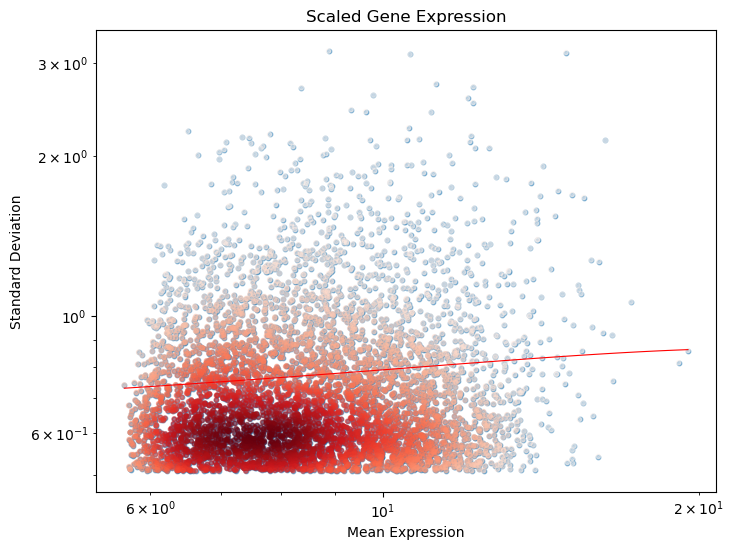

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

gene_mean = log_data_hv.mean(axis=1)
gene_sd = log_data_hv.std(axis=1)

gene_mean_safe = gene_mean + 1e-6
gene_sd_safe = gene_sd + 1e-6

plt.figure(figsize=(8,6))
plt.scatter(gene_mean_safe, gene_sd_safe, alpha=0.5, s=10)
plt.xlabel('Mean Expression')
plt.ylabel('Standard Deviation')
plt.title('Scaled Gene Expression')
plt.xscale('log')
plt.yscale('log')

xy = np.vstack([gene_mean_safe, gene_sd_safe])
z = gaussian_kde(xy)(xy)
plt.scatter(gene_mean_safe, gene_sd_safe, c=z, s=10, cmap='Reds', alpha=0.5)

from scipy.optimize import curve_fit

def poly_fit(x, a, b, c):
    return a*x**2 + b*x + c

popt, _ = curve_fit(poly_fit, gene_mean_safe, gene_sd_safe)
x_vals = np.linspace(gene_mean_safe.min(), gene_mean_safe.max(), 100)
plt.plot(x_vals, poly_fit(x_vals, *popt), color='red', linewidth=0.8)

plt.show()

# Linear analysis

In [63]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

conditions = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']
rep_dict = {cond: [col for col in hvg_5125_norm.columns if col.startswith(cond)] for cond in conditions}

cond_median = pd.DataFrame(index=hvg_5125_norm.index)
for cond, cols in rep_dict.items():
    cond_median[cond] = hvg_5125_norm[cols].median(axis=1)

slopes = []
rvalues = []
resid_df = pd.DataFrame(index=cond_median.index, columns=[c+"_resid" for c in conditions])

for gene in cond_median.index:
    y = cond_median.loc[gene, conditions].values
    x = np.arange(len(conditions))
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_pred = slope * x + intercept
    resid = y - y_pred

    slopes.append(slope)
    rvalues.append(r_value)
    resid_df.loc[gene] = resid

cond_median['slope'] = slopes
cond_median['r_value'] = rvalues
cond_median['abs_r_value'] = cond_median['r_value'].abs()
cond_median = pd.concat([cond_median, resid_df], axis=1)

r_threshold = 0.8
slope_threshold = 0.5
resid_threshold = 1

resid_sd = resid_df.astype(float).std(axis=1)

selected_genes = cond_median[
    (cond_median['abs_r_value'] > r_threshold) &
    (cond_median['slope'].abs() > slope_threshold) &
    (resid_sd < resid_threshold)
]

print(f"Selected genes: {len(selected_genes)}")


Selected genes: 12


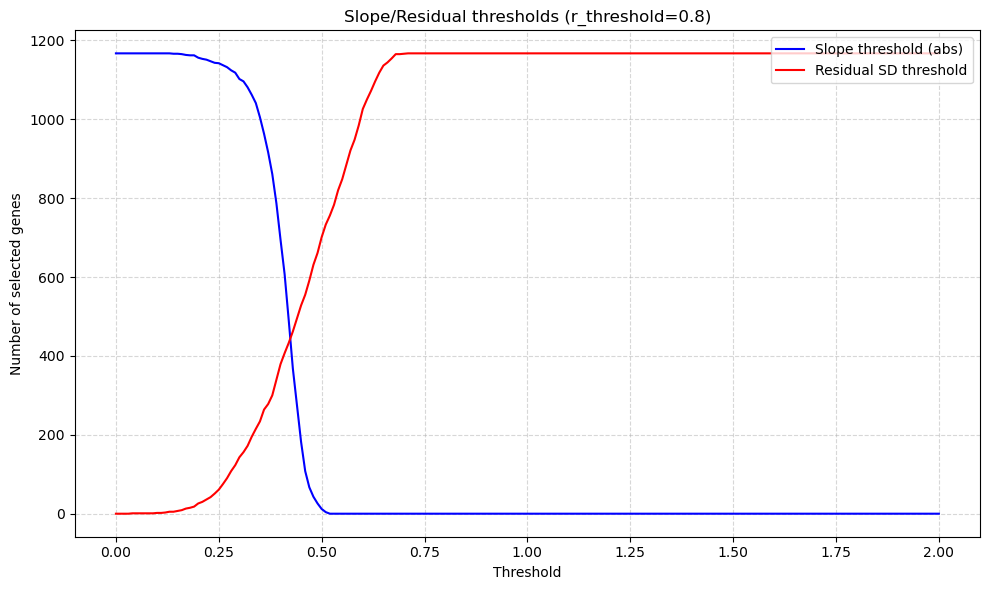

In [64]:
import matplotlib.pyplot as plt
import numpy as np

slope_thresholds = np.arange(0, 2.01, 0.01)
resid_thresholds = np.arange(0, 2.01, 0.01)

slope_counts = []
resid_counts = []

for thresh in slope_thresholds:
    selected = cond_median[
        (cond_median['abs_r_value'] > r_threshold) &
        (cond_median['slope'].abs() > thresh)
    ]
    slope_counts.append(len(selected))

for thresh in resid_thresholds:
    selected = cond_median[
        (cond_median['abs_r_value'] > r_threshold) &
        (resid_sd < thresh)
    ]
    resid_counts.append(len(selected))

plt.figure(figsize=(10,6))
plt.plot(slope_thresholds, slope_counts, label='Slope threshold (abs)', color='blue')
plt.plot(resid_thresholds, resid_counts, label='Residual SD threshold', color='red')
plt.xlabel("Threshold")
plt.ylabel("Number of selected genes")
plt.title("Slope/Residual thresholds (r_threshold=0.8)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


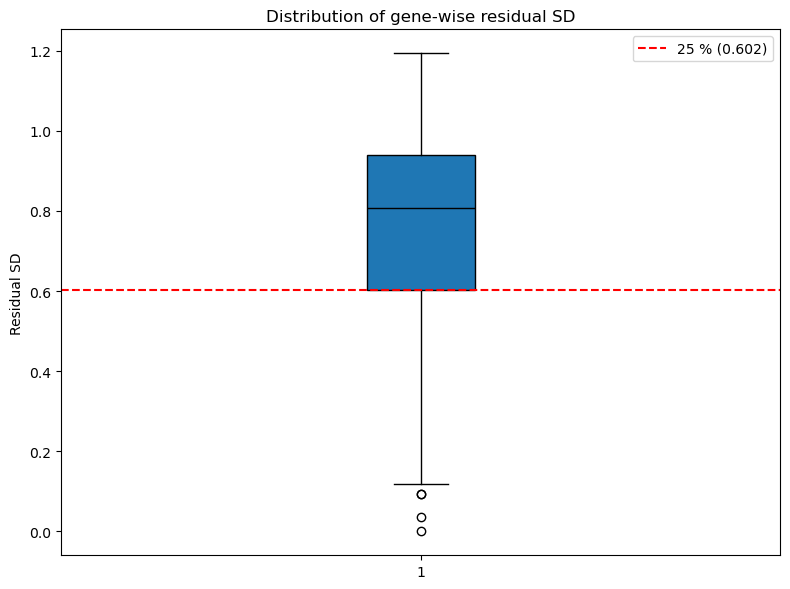

In [65]:
quantile = 0.25
resid_threshold = np.percentile(resid_sd, quantile*100)

plt.figure(figsize=(8,6))
plt.boxplot(resid_sd, vert=True, patch_artist=True, medianprops=dict(color='black'))
plt.axhline(resid_threshold, color='red', linestyle='--', label=f'{int(quantile*100)} % ({resid_threshold:.3f})')
plt.ylabel("Residual SD")
plt.title("Distribution of gene-wise residual SD")
plt.legend()
plt.tight_layout()
plt.show()


In [66]:
negative_slope_genes = cond_median[
    (cond_median['abs_r_value'] > 0.8) &
    (resid_sd < 0.602) &
    (cond_median['slope'] < 0)
]

positive_slope_genes = cond_median[
    (cond_median['abs_r_value'] > 0.8) &
    (resid_sd < 0.602) &
    (cond_median['slope'] > 0)
]

In [67]:
#####################################################
############## Positive Coeff #######################
#####################################################

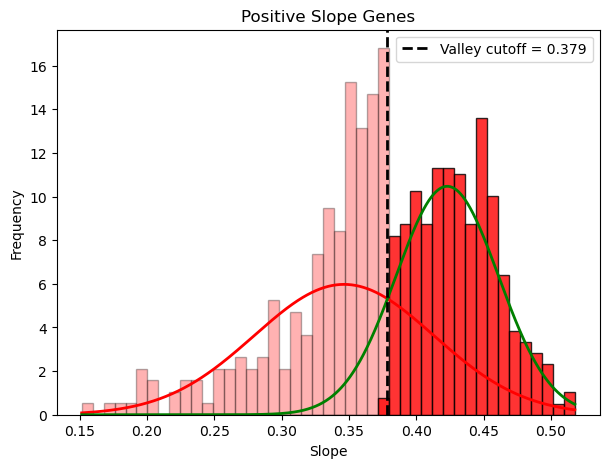

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

data = positive_slope_genes['slope'].values.flatten().reshape(-1,1)

gmm = GaussianMixture(n_components=2).fit(data)
means = gmm.means_.flatten()
variances = gmm.covariances_.flatten()
sigmas = np.sqrt(variances)

a = 1/(2*sigmas[0]**2) - 1/(2*sigmas[1]**2)
b = means[1]/(sigmas[1]**2) - means[0]/(sigmas[0]**2)
c = (means[0]**2)/(2*sigmas[0]**2) - (means[1]**2)/(2*sigmas[1]**2) + np.log(sigmas[0]/sigmas[1])
roots = np.roots([a, b, c])
valley = np.sort(roots.real[np.isclose(roots.imag,0)])
cut = None
for r in valley:
    if data.min() < r < data.max():
        cut = r
        break
if cut is None:
    cut = (means[0]+means[1])/2

binsize = 45
xmin, xmax = data.min(), data.max()
bins = np.linspace(xmin, xmax, binsize + 1)

x = np.linspace(data.min(), data.max(), 1000)
pdf1 = norm.pdf(x, means[0], sigmas[0])
pdf2 = norm.pdf(x, means[1], sigmas[1])

left_data = data[data.flatten() <= cut]
right_data = data[data.flatten() > cut]

plt.figure(figsize=(7,5))

# 같은 bins 사용
plt.hist(left_data, bins=bins, density=True, color='red', edgecolor='black', alpha=0.3)
plt.hist(right_data, bins=bins, density=True, color='red', edgecolor='black', alpha=0.8)

plt.plot(x, pdf1, lw=2, color='red')
plt.plot(x, pdf2, lw=2, color='green')
plt.axvline(cut, color='black', linestyle='--', lw=2, label=f"Valley cutoff = {cut:.3f}")

plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.title("Positive Slope Genes")
plt.legend()
plt.show()

In [69]:
import pandas as pd

high_idx = positive_slope_genes[positive_slope_genes['slope'] > 0.379].index.tolist()
low_idx = positive_slope_genes[positive_slope_genes['slope'] <= 0.379].index.tolist()

high_df = pd.DataFrame(high_idx, columns=['Gene'])
low_df = pd.DataFrame(low_idx, columns=['Gene'])

high_df.to_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/positive_slope_high.csv", index=False)
low_df.to_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/positive_slope_low.csv", index=False)

In [70]:
gene_list = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/positive_slope_high.csv",header=None, sep="\t")

/tmp/ipykernel_2402698/943235976.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))


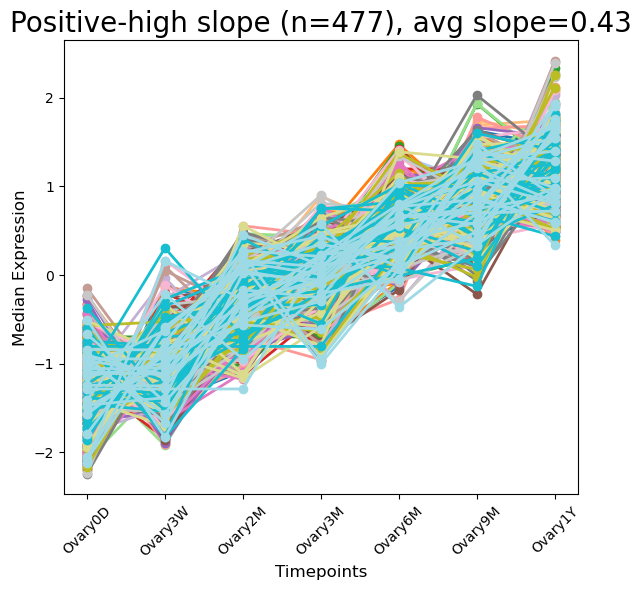

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

pos_high_genes = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/positive_slope_high.csv", index_col=0)
pos_high_genes_list = pos_high_genes.index.intersection(positive_slope_genes.index)

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']
x_vals = np.arange(len(timepoints))

plt.figure(figsize=(6,6))
colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))

slopes_all = []

for i, gene in enumerate(pos_high_genes_list):
    medians = []
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        median_val = hvg_5125_norm_ordered.loc[gene, cols].median()
        medians.append(median_val)
    
    # 선형회귀 slope 계산
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, medians)
    slopes_all.append(slope)
    
    # plot
    plt.plot(timepoints, medians, marker='o', linewidth=2, label=f"{gene} (slope={slope:.2f})", color=colors(i))
    
# 평균 slope
mean_slope = np.mean(slopes_all)
plt.title(f"Positive-high slope (n={len(pos_high_genes_list)}), avg slope={mean_slope:.2f}", fontsize=20)

plt.xticks(rotation=45)
plt.xlabel("Timepoints", fontsize=12)
plt.ylabel("Median Expression", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2402698/3047668102.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))


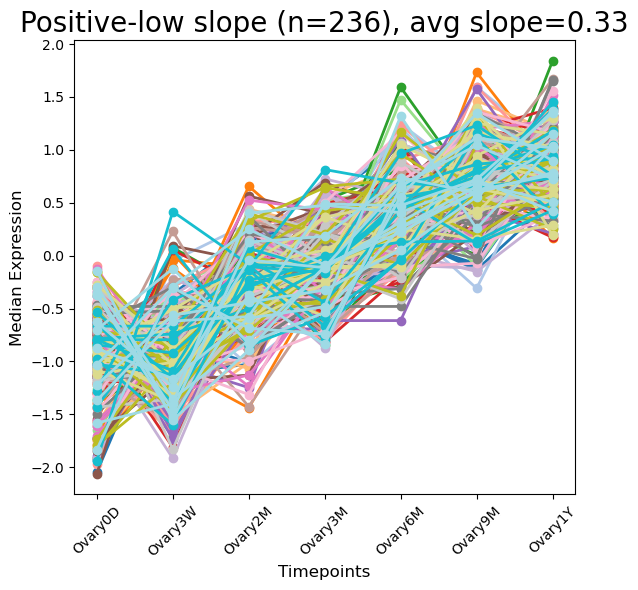

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

pos_high_genes = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/positive_slope_low.csv", index_col=0)
pos_high_genes_list = pos_high_genes.index.intersection(positive_slope_genes.index)

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']
x_vals = np.arange(len(timepoints))

plt.figure(figsize=(6,6))
colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))

slopes_all = []

for i, gene in enumerate(pos_high_genes_list):
    medians = []
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        median_val = hvg_5125_norm_ordered.loc[gene, cols].median()
        medians.append(median_val)
    
    # 선형회귀 slope 계산
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, medians)
    slopes_all.append(slope)
    
    # plot
    plt.plot(timepoints, medians, marker='o', linewidth=2, label=f"{gene} (slope={slope:.2f})", color=colors(i))
    
# 평균 slope
mean_slope = np.mean(slopes_all)
plt.title(f"Positive-low slope (n={len(pos_high_genes_list)}), avg slope={mean_slope:.2f}", fontsize=20)

plt.xticks(rotation=45)
plt.xlabel("Timepoints", fontsize=12)
plt.ylabel("Median Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [467]:
#####################################################
############## Negative Coeff #######################
#####################################################

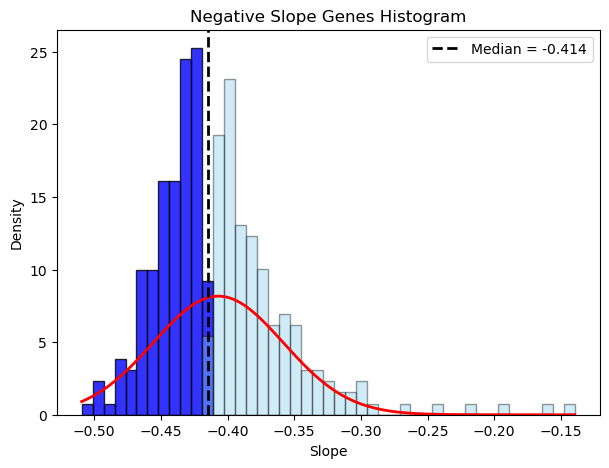

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

data = negative_slope_genes['slope'].values.flatten().reshape(-1,1)

gmm = GaussianMixture(n_components=1).fit(data)
mean = gmm.means_[0,0]
sigma = np.sqrt(gmm.covariances_[0,0])

median_val = np.median(data)

binsize = 45
xmin, xmax = data.min(), data.max()
bins = np.linspace(xmin, xmax, binsize + 1)

x = np.linspace(xmin, xmax, 1000)
pdf = norm.pdf(x, mean, sigma)

left_data = data[data.flatten() <= median_val]
right_data = data[data.flatten() > median_val]

plt.figure(figsize=(7,5))
plt.hist(left_data, bins=bins, density=True, color='blue', edgecolor='black', alpha=0.8)
plt.hist(right_data, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.4)
plt.plot(x, pdf, lw=2, color='red')
plt.axvline(median_val, color='black', linestyle='--', lw=2, label=f"Median = {median_val:.3f}")
plt.xlabel("Slope")
plt.ylabel("Density")
plt.title("Negative Slope Genes Histogram")
plt.legend()
plt.show()

In [79]:
import pandas as pd

high_idx = negative_slope_genes[negative_slope_genes['slope'] <= -0.414].index.tolist()
low_idx = negative_slope_genes[negative_slope_genes['slope'] > -0.414].index.tolist()

high_df = pd.DataFrame(high_idx, columns=['Gene'])
low_df = pd.DataFrame(low_idx, columns=['Gene'])

high_df.to_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/negative_slope_high.csv", index=False)
low_df.to_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/negative_slope_low.csv", index=False)

In [505]:
################################################
############## Total plot#######################
################################################

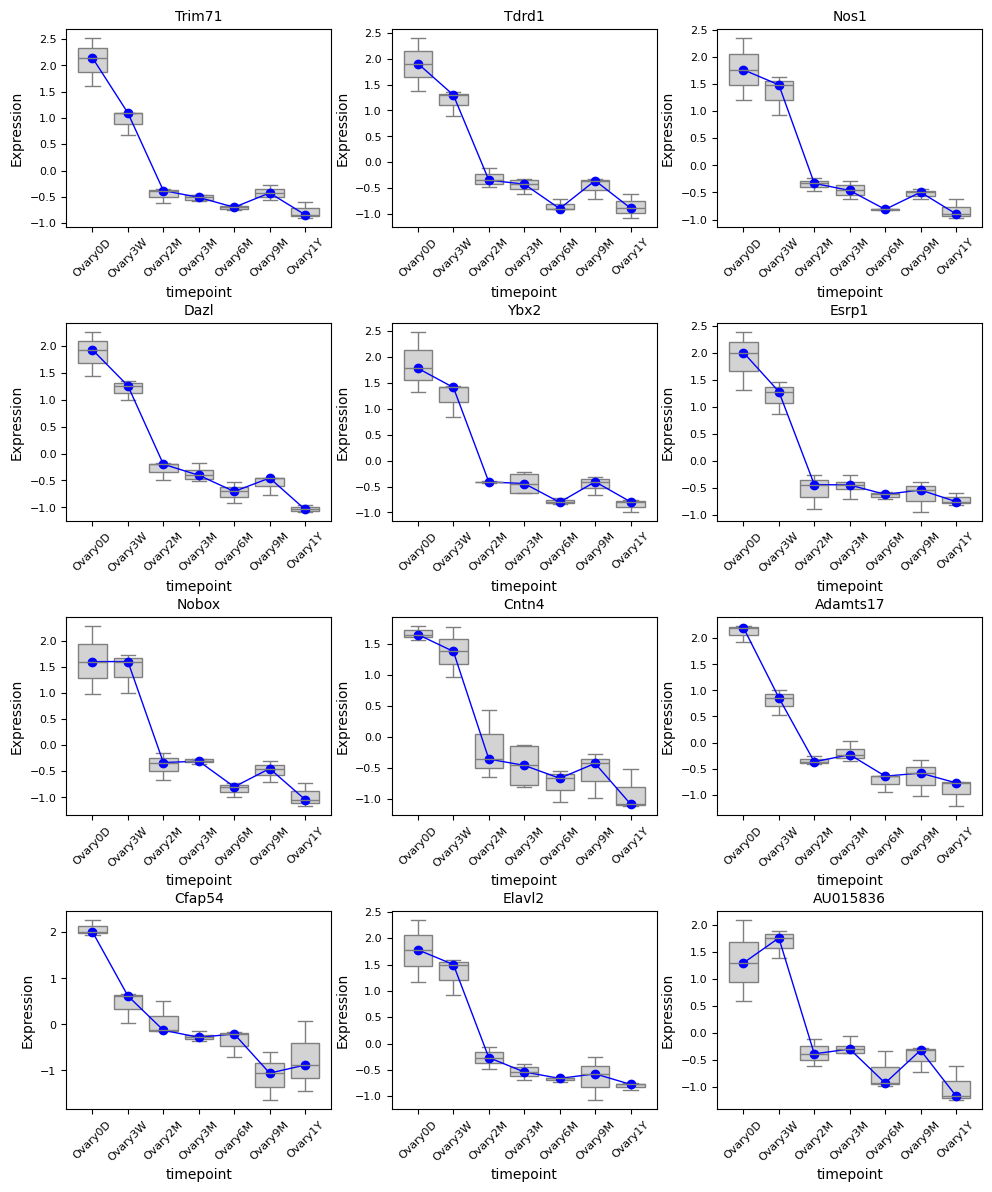

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

genes_to_plot = ['Trim71',
 'Tdrd1',
 'Nos1',
 'Dazl',
 'Ybx2',
 'Esrp1',
 'Nobox',
 'Cntn4',
 'Adamts17',
 'Cfap54',
 'Elavl2',
 'AU015836']

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']

plt.figure(figsize=(10, 12))
n_genes = len(genes_to_plot)
n_cols = 3
n_rows = (n_genes + n_cols - 1) // n_cols

for i, gene in enumerate(genes_to_plot):
    ax = plt.subplot(n_rows, n_cols, i+1)
    gene_df = pd.DataFrame()
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        temp = pd.DataFrame({
            'timepoint': tp,
            'expression': hvg_5125_norm_ordered.loc[gene, cols].values
        })
        gene_df = pd.concat([gene_df, temp], axis=0)
    
    sns.boxplot(x='timepoint', y='expression', data=gene_df, color='lightgray', showfliers=False, ax=ax)
    
    median_vals = [gene_df[gene_df['timepoint']==tp]['expression'].median() for tp in timepoints]
    ax.plot(timepoints, median_vals, color='blue', marker='o', linewidth=1)
    
    ax.set_title(gene, fontsize=10)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylabel("Expression", fontsize=10)

plt.tight_layout(pad=1.0, h_pad=0.3, w_pad=0.3)
plt.show()


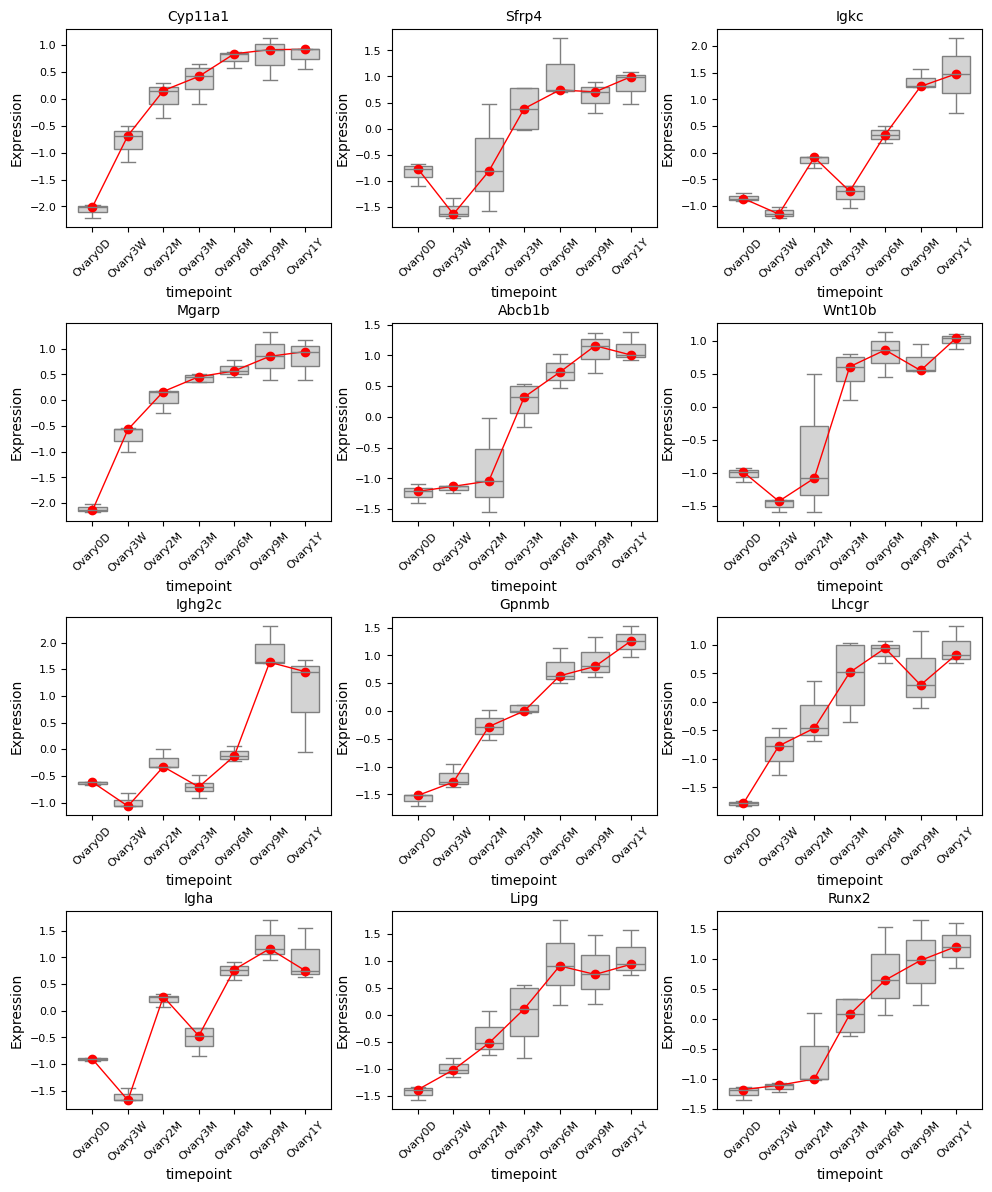

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

genes_to_plot = ['Cyp11a1',
 'Sfrp4',
 'Igkc',
 'Mgarp',
 'Abcb1b',
 'Wnt10b',
 'Ighg2c',
 'Gpnmb',
 'Lhcgr',
 'Igha',
 'Lipg',
 'Runx2']

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']

plt.figure(figsize=(10, 12))
n_genes = len(genes_to_plot)
n_cols = 3
n_rows = (n_genes + n_cols - 1) // n_cols

for i, gene in enumerate(genes_to_plot):
    ax = plt.subplot(n_rows, n_cols, i+1)
    gene_df = pd.DataFrame()
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        temp = pd.DataFrame({
            'timepoint': tp,
            'expression': hvg_5125_norm_ordered.loc[gene, cols].values
        })
        gene_df = pd.concat([gene_df, temp], axis=0)
    
    sns.boxplot(x='timepoint', y='expression', data=gene_df, color='lightgray', showfliers=False, ax=ax)
    
    median_vals = [gene_df[gene_df['timepoint']==tp]['expression'].median() for tp in timepoints]
    ax.plot(timepoints, median_vals, color='red', marker='o', linewidth=1)
    
    ax.set_title(gene, fontsize=10)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylabel("Expression", fontsize=10)

plt.tight_layout(pad=1.0, h_pad=0.3, w_pad=0.3)
plt.show()


/tmp/ipykernel_2402698/2375457553.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))


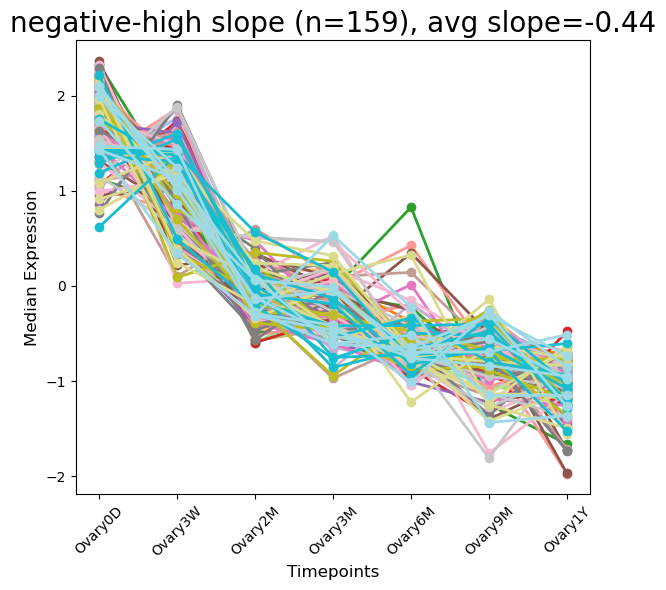

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

pos_high_genes = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/negative_slope_high.csv", index_col=0)
pos_high_genes_list = pos_high_genes.index.intersection(negative_slope_genes.index)

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']
x_vals = np.arange(len(timepoints))

plt.figure(figsize=(6,6))
colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))

slopes_all = []

for i, gene in enumerate(pos_high_genes_list):
    medians = []
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        median_val = hvg_5125_norm_ordered.loc[gene, cols].median()
        medians.append(median_val)
    
    # 선형회귀 slope 계산
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, medians)
    slopes_all.append(slope)
    
    # plot
    plt.plot(timepoints, medians, marker='o', linewidth=2, label=f"{gene} (slope={slope:.2f})", color=colors(i))
    
# 평균 slope
mean_slope = np.mean(slopes_all)
plt.title(f"negative-high slope (n={len(pos_high_genes_list)}), avg slope={mean_slope:.2f}", fontsize=20)

plt.xticks(rotation=45)
plt.xlabel("Timepoints", fontsize=12)
plt.ylabel("Median Expression", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2402698/2231687022.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))


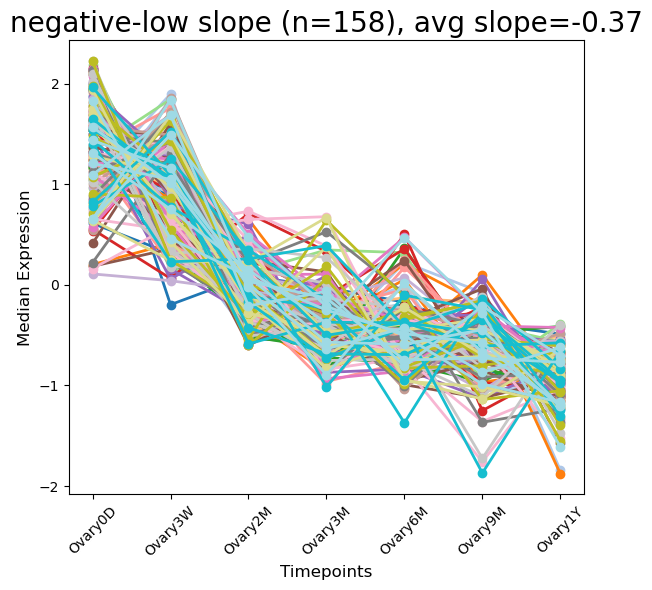

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

pos_high_genes = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/negative_slope_low.csv", index_col=0)
pos_high_genes_list = pos_high_genes.index.intersection(negative_slope_genes.index)

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']
x_vals = np.arange(len(timepoints))

plt.figure(figsize=(6,6))
colors = plt.cm.get_cmap('tab20', len(pos_high_genes_list))

slopes_all = []

for i, gene in enumerate(pos_high_genes_list):
    medians = []
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        median_val = hvg_5125_norm_ordered.loc[gene, cols].median()
        medians.append(median_val)
    
    # 선형회귀 slope 계산
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, medians)
    slopes_all.append(slope)
    
    # plot
    plt.plot(timepoints, medians, marker='o', linewidth=2, label=f"{gene} (slope={slope:.2f})", color=colors(i))
    
# 평균 slope
mean_slope = np.mean(slopes_all)
plt.title(f"negative-low slope (n={len(pos_high_genes_list)}), avg slope={mean_slope:.2f}", fontsize=20)

plt.xticks(rotation=45)
plt.xlabel("Timepoints", fontsize=12)
plt.ylabel("Median Expression", fontsize=12)
plt.tight_layout()
plt.show()

# Non Linear model

In [196]:
# data_raw = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_raw.csv", index_col=0) # raw
data = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_vsd_preprocess.csv", index_col=0) # vsd preprocess
# data = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_rld_preprocess.csv", index_col=0) # vsd preprocess

In [197]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

def analyze_peak_genes(data_path, target_timepoint, r2_cutoff=0.64):
    data = pd.read_csv(data_path, index_col=0)
    time_points = [re.search(r'Ovary(\d+[DWMY])', col).group(1) for col in data.columns]
    data_time = data.copy()
    data_time.columns = pd.MultiIndex.from_arrays([time_points, data.columns])
    median_df = data_time.groupby(level=0, axis=1).median()
    
    def convert_to_day(tp):
        num = int(re.findall(r'\d+', tp)[0])
        if 'D' in tp:
            return num
        elif 'W' in tp:
            return num * 7
        elif 'M' in tp:
            return num * 30
        elif 'Y' in tp:
            return num * 365
    
    median_df.columns = [convert_to_day(tp) for tp in median_df.columns]
    median_df = median_df.sort_index(axis=1)
    
    print(f"정렬된 컬럼: {list(median_df.columns)}")
    
    timepoint_idx = list(median_df.columns).index(target_timepoint)
    genes_sorted = median_df[median_df.idxmax(axis=1) == target_timepoint].index.tolist()
    print(f"Timepoint {target_timepoint}에서 최대값 유전자 수: {len(genes_sorted)}")
    
    def slope_by_index(y_vals):
        n = len(y_vals)
        if n < 2:
            return 0
        x = np.arange(n)
        x_mean = np.mean(x)
        y_mean = np.mean(y_vals)
        slope = np.sum((x - x_mean) * (y_vals - y_mean)) / np.sum((x - x_mean)**2)
        return slope
    
    def r2_by_index(y_vals):
        x = np.arange(len(y_vals))
        return np.corrcoef(x, y_vals)[0,1]**2
    
    pos_genes = []
    r2_dict = {}
    slope_before_dict = {}
    slope_after_dict = {}
    
    for gene in genes_sorted:
        y = median_df.loc[gene].values
        y_before = y[:timepoint_idx+1]
        y_after = y[timepoint_idx:]
        
        if len(y_before) < 2 or len(y_after) < 2:
            continue
        
        slope_before = slope_by_index(y_before)
        slope_after = slope_by_index(y_after)
        
        r2_dict[gene] = r2_by_index(y)
        slope_before_dict[gene] = slope_before
        slope_after_dict[gene] = slope_after
        
        if slope_before > 0 and slope_after < 0:
            pos_genes.append(gene)
    
    print(f"Slope (+/-) 선별 유전자 수: {len(pos_genes)}")
    
    final_genes = [gene for gene in pos_genes if r2_dict[gene] > r2_cutoff]
    print(f"R² > {r2_cutoff} 유전자 수: {len(final_genes)}")
    
    slopes_before = [slope_before_dict[gene] for gene in final_genes]
    slopes_after = [slope_after_dict[gene] for gene in final_genes]

    q75_before = np.quantile(np.abs(slopes_before), 0.75)
    q25_after = -np.quantile(np.abs(slopes_after), 0.75)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(slopes_before, bins=30, color='blue', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Slope (Before)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Positive slope (Before)')
    axes[0].axvline(q75_before, color='red', linestyle='--', linewidth=2,
                    label=f'Q75(abs): {q75_before:.4f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(slopes_after, bins=30, color='orange', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Slope (After)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Negative slope (After)')
    axes[1].axvline(q25_after, color='red', linestyle='--', linewidth=2,
                    label=f'≤ Q25(abs): {q25_after:.4f}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    strong_genes = []
    for gene in final_genes:
        sb = slope_before_dict[gene]
        sa = slope_after_dict[gene]
        if sb >= q75_before and sa <= q25_after:
            strong_genes.append(gene)

    print(f"Quantile 기반 최종 강한 peak genes 수: {len(strong_genes)}")

    return strong_genes, median_df, slope_before_dict, slope_after_dict, r2_dict


/tmp/ipykernel_3831812/3221255823.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = data_time.groupby(level=0, axis=1).median()


정렬된 컬럼: [0, 21, 60, 90, 180, 270, 365]
Timepoint 270에서 최대값 유전자 수: 3866
Slope (+/-) 선별 유전자 수: 3661
R² > 0.64 유전자 수: 656


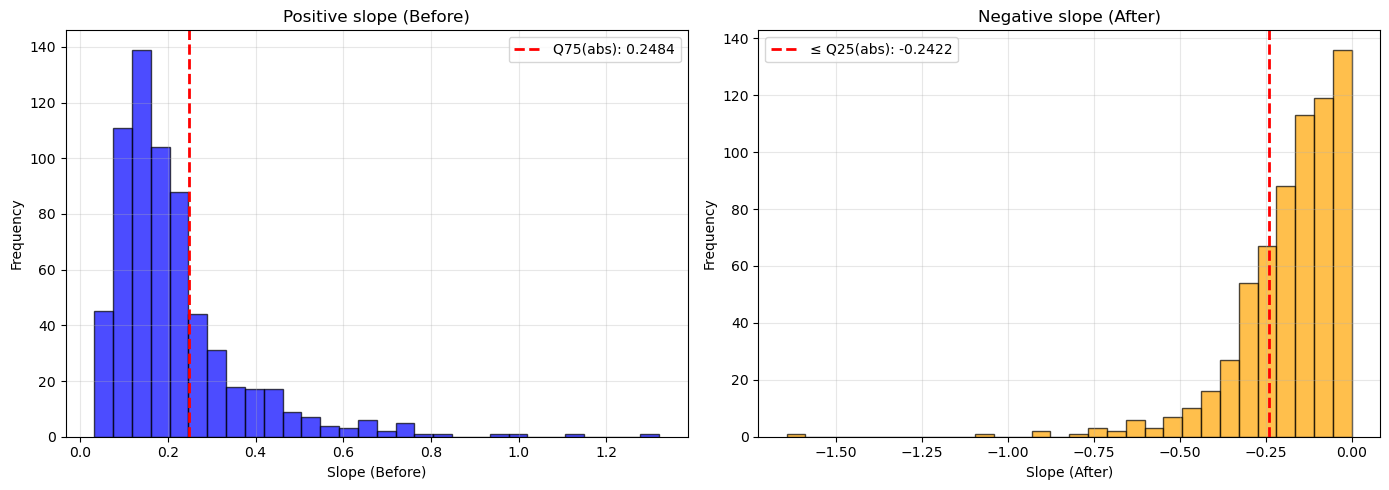

Quantile 기반 최종 강한 peak genes 수: 83


In [201]:
data_path = "/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_vsd_preprocess.csv"
target_timepoint = 270
r2_cutoff = 0.64

final_genes, median_df, slope_before_dict, slope_after_dict, r2_dict = analyze_peak_genes(
    data_path=data_path,
    target_timepoint=target_timepoint,
    r2_cutoff=r2_cutoff
)

In [202]:
data = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_vsd_preprocess.csv", index_col=0)
#data = pd.read_csv("/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_rld_preprocess.csv", index_col=0)
tp = data.columns.str.extract(r'(Ovary\d+[DMWY])')[0]
df = data.copy()
df.columns = tp
median_df = df.groupby(df.columns, axis=1).median()

/tmp/ipykernel_3831812/2789220480.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = df.groupby(df.columns, axis=1).median()


/tmp/ipykernel_3831812/3152839270.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(df_plot.values, labels=tp_order, widths=0.5, patch_artist=True, zorder=1)


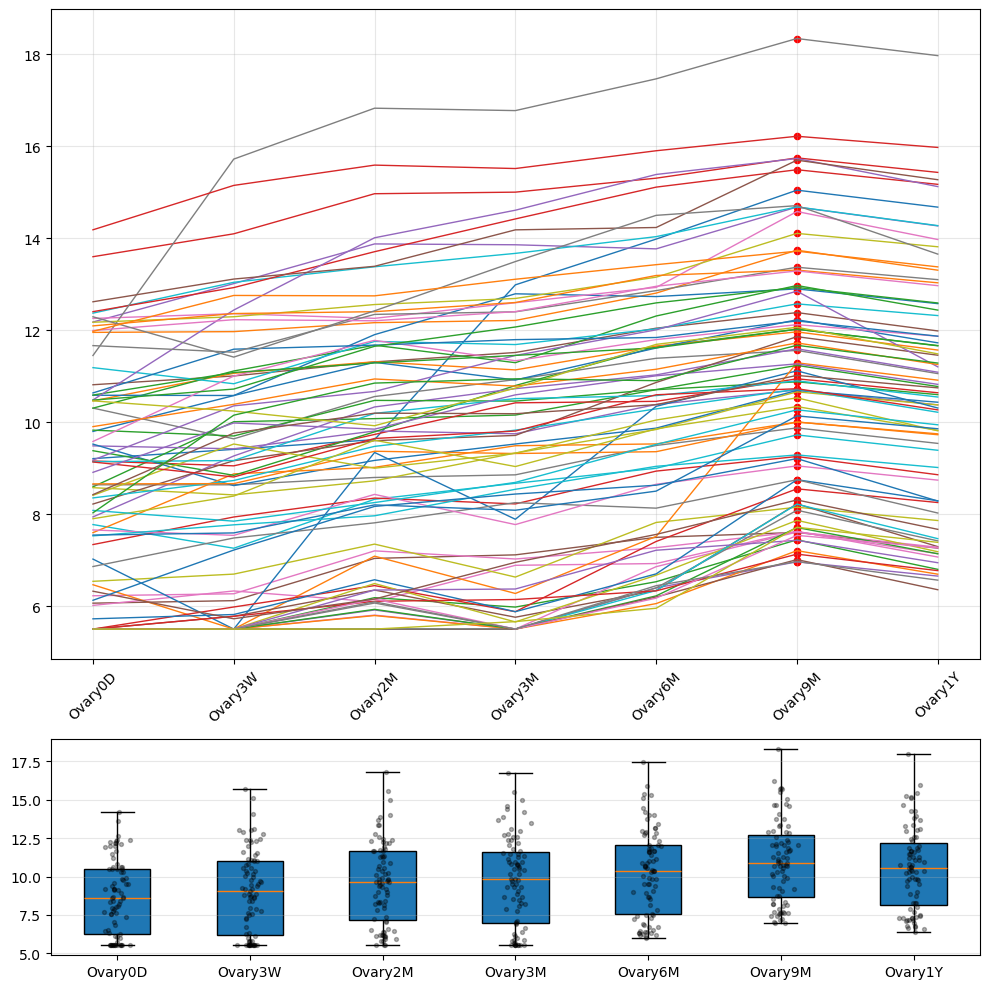

In [206]:
tp_order = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']

df_plot = median_df.loc[final_genes]
df_plot = df_plot.reindex(columns=tp_order)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios':[3,1]})

x = list(range(len(tp_order)))

for g in df_plot.index:
    y = df_plot.loc[g].values
    axes[0].plot(x, y, linewidth=1)
    peak_idx = y.argmax()
    axes[0].scatter(peak_idx, y[peak_idx], s=20, color='red')

axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tp_order, rotation=45)

bp = axes[1].boxplot(df_plot.values, labels=tp_order, widths=0.5, patch_artist=True, zorder=1)
axes[1].grid(True, axis='y', alpha=0.3)

for i, col in enumerate(tp_order):
    y_vals = df_plot[col].values
    x_vals = np.random.normal(i + 1, 0.04, size=len(y_vals))
    axes[1].scatter(
        x_vals, y_vals,
        color='black',
        s=8,
        alpha=0.3,   # 투명도 증가
        zorder=3     # boxplot 앞에 두기
    )

plt.tight_layout()
plt.show()


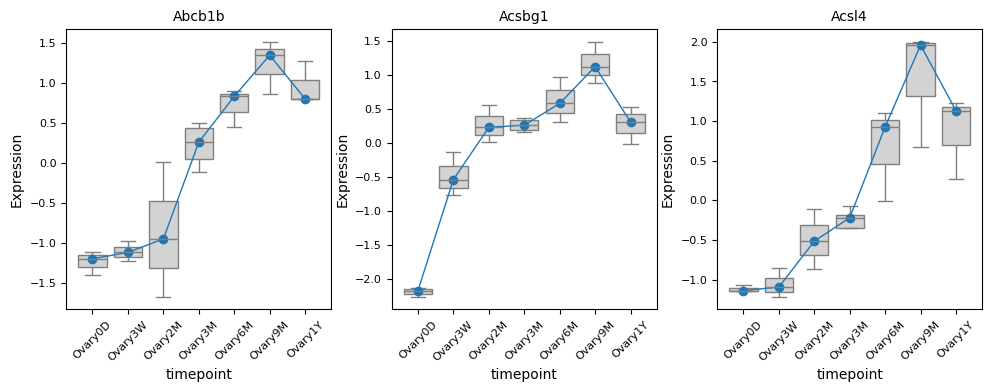

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

genes_to_plot = [
'Abcb1b','Abcb7','Abhd3','Abhd4','Acad10','Acad8','Acadm','Acbd5','Aco2','Acox3','Acp6','Acsbg1','Cdk18','Acsl4'
]

existing_genes = [g for g in genes_to_plot if g in hvg_5125_norm_ordered.index]

timepoints = ['Ovary0D','Ovary3W','Ovary2M','Ovary3M','Ovary6M','Ovary9M','Ovary1Y']

plt.figure(figsize=(10, 4))
n_genes = len(existing_genes)
n_cols = 3
n_rows = (n_genes + n_cols - 1) // n_cols

for i, gene in enumerate(existing_genes):
    ax = plt.subplot(n_rows, n_cols, i+1)
    gene_df = pd.DataFrame()
    for tp in timepoints:
        cols = [col for col in hvg_5125_norm_ordered.columns if col.startswith(tp)]
        temp = pd.DataFrame({
            'timepoint': tp,
            'expression': hvg_5125_norm_ordered.loc[gene, cols].values
        })
        gene_df = pd.concat([gene_df, temp], axis=0)
    
    sns.boxplot(x='timepoint', y='expression', data=gene_df, color='lightgray', showfliers=False, ax=ax)
    median_vals = [gene_df[gene_df['timepoint']==tp]['expression'].median() for tp in timepoints]
    ax.plot(timepoints, median_vals, marker='o', linewidth=1)
    ax.set_title(gene, fontsize=10)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylabel("Expression", fontsize=10)

plt.tight_layout(pad=1.0, h_pad=0.3, w_pad=0.3)
plt.show()


/tmp/ipykernel_3831812/1511789610.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = data_time.groupby(level=0, axis=1).median()
/tmp/ipykernel_3831812/1511789610.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = data_time.groupby(level=0, axis=1).median()
/tmp/ipykernel_3831812/1511789610.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = data_time.groupby(level=0, axis=1).median()
/tmp/ipykernel_3831812/1511789610.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = data_time.groupby(level=0, axis=1).median()
/tmp/ipykernel_3831812/1511789610.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  median_df = data_time

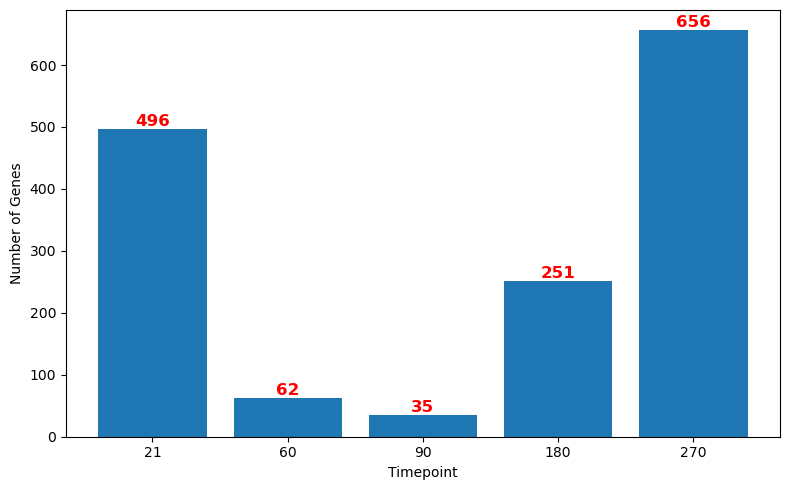

In [175]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

def analyze_peak_genes_no_plot(data_path, target_timepoint, r2_cutoff=0.64):
    data = pd.read_csv(data_path, index_col=0)
    time_points = [re.search(r'Ovary(\d+[DWMY])', col).group(1) for col in data.columns]
    data_time = data.copy()
    data_time.columns = pd.MultiIndex.from_arrays([time_points, data.columns])
    median_df = data_time.groupby(level=0, axis=1).median()

    def convert_to_day(tp):
        num = int(re.findall(r'\d+', tp)[0])
        if 'D' in tp: return num
        if 'W' in tp: return num * 7
        if 'M' in tp: return num * 30
        if 'Y' in tp: return num * 365

    median_df.columns = [convert_to_day(tp) for tp in median_df.columns]
    median_df = median_df.sort_index(axis=1)

    timepoint_idx = list(median_df.columns).index(target_timepoint)
    genes_sorted = median_df[median_df.idxmax(axis=1) == target_timepoint].index.tolist()

    def slope(y):
        x = np.arange(len(y))
        return np.polyfit(x, y, 1)[0]

    def r2(y):
        x = np.arange(len(y))
        return np.corrcoef(x, y)[0,1]**2

    pos_genes = []
    r2_dict = {}
    slope_before_dict = {}
    slope_after_dict = {}

    for gene in genes_sorted:
        y = median_df.loc[gene].values
        y_before = y[:timepoint_idx+1]
        y_after = y[timepoint_idx:]
        if len(y_before) < 2 or len(y_after) < 2:
            continue

        sb = slope(y_before)
        sa = slope(y_after)
        r2_dict[gene] = r2(y)
        slope_before_dict[gene] = sb
        slope_after_dict[gene] = sa

        if sb > 0 and sa < 0:
            pos_genes.append(gene)

    final_genes = [g for g in pos_genes if r2_dict[g] > r2_cutoff]
    return final_genes

data_path = "/home/Data_Drive_8TB/kykim/4. RNA_seq_practice/bulk_rna_vsd_preprocess.csv"
r2_cutoff = 0.64
timepoints = [21, 60, 90, 180, 270]

gene_counts = []
for tp in timepoints:
    genes = analyze_peak_genes_no_plot(data_path=data_path, target_timepoint=tp, r2_cutoff=r2_cutoff)
    gene_counts.append(len(genes))

plt.figure(figsize=(8,5))
plt.bar([str(tp) for tp in timepoints], gene_counts)

for i, v in enumerate(gene_counts):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12, color='red', fontweight='bold')

plt.xlabel("Timepoint")
plt.ylabel("Number of Genes")
plt.tight_layout()
plt.show()